<a href="https://colab.research.google.com/github/stewistzz/SBP_Model_UTS/blob/main/UTS_PBL_SMARTPEAK_DIMAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Langkah 1 : Import Library yang Digunakan**

In [20]:
# Install libraries (run once in Colab)
# !pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# ─── Plot style ───────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = ['#4C72B0','#DD8452','#55A868','#C44E52']
CHRON_MAP_COLORS = {
    'Lion':'#F4A261', 'Bear':'#2A9D8F', 'Wolf':'#6C63FF', 'Dolphin':'#E9C46A'
}

**Langkah 2 : Import Dataset yang Digunakan(Smartpeak)**

In [21]:
file_path = "/content/study_habits_sample.csv"
# lakukan import dataset
df_raw = pd.read_csv(file_path)
# proses dataset untuk dilakukan read

print(f"Shape awal: {df_raw.shape}")
df_raw.head()
# tampilkan 5 data teratas untuk pengecekan dataset berhasil diimport

Shape awal: (10000, 12)


,habit_id,student_id,study_hours_weekly,study_location,preferred_study_time,study_method,procrastination_level,organization_level,uses_study_aids,academic_term,academic_year,country
0,NGA_HAB_00075721,NGA_STU_00037734,5.1,Home,Afternoon,Group Study,4.0,3.0,True,Term 3,2023/2024,Nigeria
1,NGA_HAB_00080184,NGA_STU_00068308,NaN,Home,Evening,Note-taking,3.0,3.0,True,Term 3,2023/2024,Nigeria
2,NGA_HAB_00019864,NGA_STU_00043560,4.3,Home,Variable,Practice Problems,5.0,4.0,True,Term 2,2023/2024,Nigeria
3,NGA_HAB_00076699,NGA_STU_00029039,13.8,Home,Evening,Note-taking,3.0,5.0,True,Term 1,2024/2025,Nigeria
4,NGA_HAB_00092991,NGA_STU_00040175,12.3,Home,Afternoon,Note-taking,3.0,2.0,True,Term 3,2023/2024,Nigeria


Langklah 3 : Melakukan Eksplorasi dataset untuk mendapatkan Informasi

INFORMASI UMUM DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   habit_id               10000 non-null  object 
 1   student_id             10000 non-null  object 
 2   study_hours_weekly     9816 non-null   float64
 3   study_location         9901 non-null   object 
 4   preferred_study_time   9912 non-null   object 
 5   study_method           9906 non-null   object 
 6   procrastination_level  9801 non-null   float64
 7   organization_level     9807 non-null   float64
 8   uses_study_aids        10000 non-null  bool   
 9   academic_term          9874 non-null   object 
 10  academic_year          9903 non-null   object 
 11  country                9903 non-null   object 
dtypes: bool(1), float64(3), object(8)
memory usage: 869.3+ KB

📊 Analsis Statistik Deskriptif
🔴 Missing Values per Kolom:
                  

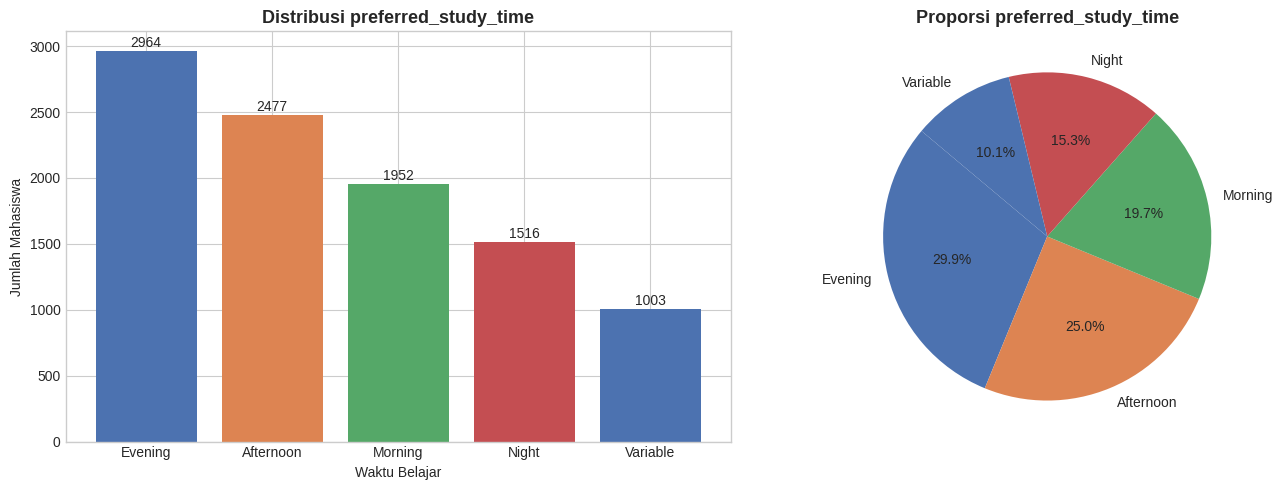


📌 Catatan: Kolom preferred_study_time akan menjadi DASAR pemberian label chronotype.


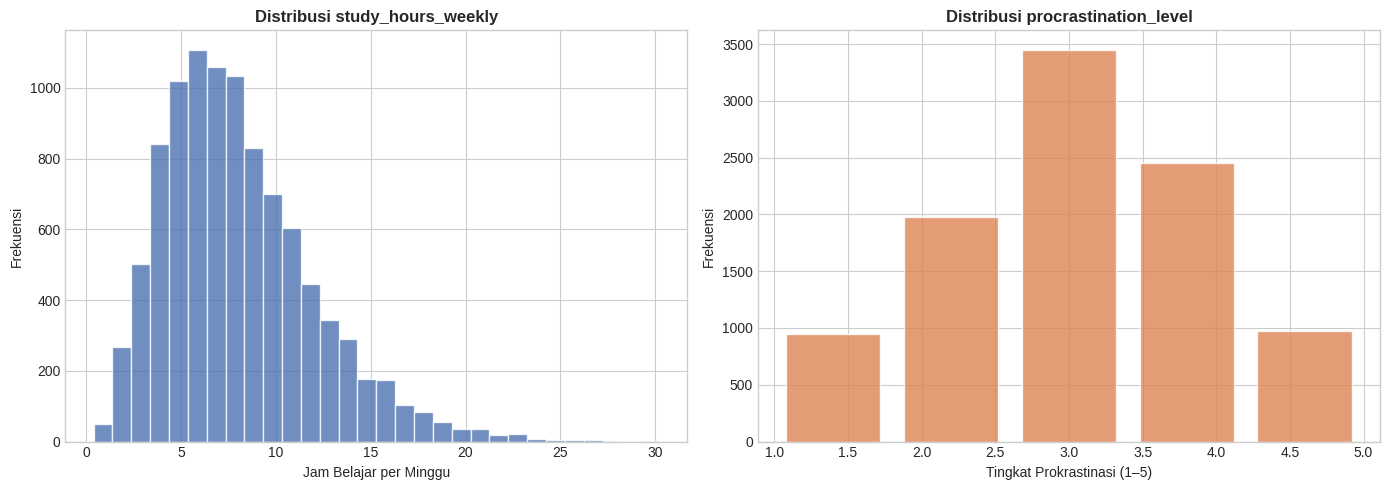

In [22]:
# langkah 1 mendapatkan informasi umum
print("=" * 55)
print("INFORMASI UMUM DATASET")
print("=" * 55)
df_raw.info()

# langkah 2 analisas statistik deskriptif
print("\n📊 Analsis Statistik Deskriptif")
df_raw.describe(include='all').T

# ─langkah 3 Missing values per kolom ────────────────────────────────
print("🔴 Missing Values per Kolom:")
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

# langkah 4 Distribusi variabel target: preferred_study_time ────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
time_counts = df_raw['preferred_study_time'].value_counts()
axes[0].bar(time_counts.index, time_counts.values, color=COLORS[:len(time_counts)])
axes[0].set_title('Distribusi preferred_study_time', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Waktu Belajar')
axes[0].set_ylabel('Jumlah Mahasiswa')
for i, v in enumerate(time_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontsize=10)

# Pie chart
axes[1].pie(time_counts.values, labels=time_counts.index, autopct='%1.1f%%',
            colors=COLORS[:len(time_counts)], startangle=140)
axes[1].set_title('Proporsi preferred_study_time', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()
print("\n📌 Catatan: Kolom preferred_study_time akan menjadi DASAR pemberian label chronotype.")

# langkah 5 Distribusi variabel numerik ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_raw['study_hours_weekly'].dropna(), bins=30, color='#4C72B0',
             edgecolor='white', alpha=0.8)
axes[0].set_title('Distribusi study_hours_weekly', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Jam Belajar per Minggu')
axes[0].set_ylabel('Frekuensi')

axes[1].hist(df_raw['procrastination_level'].dropna(), bins=5, color='#DD8452',
             edgecolor='white', alpha=0.8, rwidth=0.8)
axes[1].set_title('Distribusi procrastination_level', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tingkat Prokrastinasi (1–5)')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

Langkah 4 : Melakukan Selesi fitur yang telah disepakati
study_hours_weekly
1. study_hours_weekly
2. study_location
3. preferred_study_time
4. study_method
5. procrastination_level
6. uses_study_aids

In [23]:
# ────────────────────────────────────────────────────────────────
# LANGKAH 1: Seleksi Fitur (Feature Selection)
# Ambil hanya 6 variabel yang telah ditentukan kelompok
# ────────────────────────────────────────────────────────────────
SELECTED_FEATURES = [
    'study_hours_weekly',   # numerik kontinu
    'study_location',       # kategorikal nominal
    'preferred_study_time', # kategorikal ordinal (juga dasar label)
    'study_method',         # kategorikal nominal
    'procrastination_level',# numerik ordinal (1–5)
    'uses_study_aids'       # boolean
]

df = df_raw[SELECTED_FEATURES].copy()

print(f"✅ Fitur dipilih: {SELECTED_FEATURES}")
print(f"✅ Shape setelah seleksi fitur: {df.shape}")
df.head(3)


✅ Fitur dipilih: ['study_hours_weekly', 'study_location', 'preferred_study_time', 'study_method', 'procrastination_level', 'uses_study_aids']
✅ Shape setelah seleksi fitur: (10000, 6)


,study_hours_weekly,study_location,preferred_study_time,study_method,procrastination_level,uses_study_aids
0,5.1,Home,Afternoon,Group Study,4.0,True
1,NaN,Home,Evening,Note-taking,3.0,True
2,4.3,Home,Variable,Practice Problems,5.0,True


Langkah 5 : Cleaning Data

In [24]:
# ────────────────────────────────────────────────────────────────
# LANGKAH 2: Data Cleaning
# ────────────────────────────────────────────────────────────────

print("=" * 55)
print("SEBELUM CLEANING")
print("=" * 55)
print(f"Total baris: {len(df)}")
print(f"Total missing values:\n{df.isnull().sum()}\n")

# 2a. Hapus baris duplikat
n_dup = df.duplicated().sum()
df.drop_duplicates(inplace=True)
print(f"🗑️  Baris duplikat dihapus : {n_dup}")

# 2b. Tangani missing values
#     - study_hours_weekly   → isi dengan median (robust terhadap outlier)
#     - procrastination_level→ isi dengan median
#     - study_location       → isi dengan modus
#     - preferred_study_time → HAPUS baris (krusial untuk labeling)
#     - study_method         → isi dengan modus
#     - uses_study_aids      → isi dengan modus

before = len(df)
df.dropna(subset=['preferred_study_time'], inplace=True)
print(f"🗑️  Baris tanpa preferred_study_time dihapus: {before - len(df)}")

df['study_hours_weekly'].fillna(df['study_hours_weekly'].median(), inplace=True)
df['procrastination_level'].fillna(df['procrastination_level'].median(), inplace=True)
df['study_location'].fillna(df['study_location'].mode()[0], inplace=True)
df['study_method'].fillna(df['study_method'].mode()[0], inplace=True)
df['uses_study_aids'].fillna(df['uses_study_aids'].mode()[0], inplace=True)

print(f"\n✅ Missing values setelah cleaning:")
print(df.isnull().sum())

print(f"\n📏 Shape setelah cleaning: {df.shape}")

SEBELUM CLEANING
Total baris: 10000
Total missing values:
study_hours_weekly       184
study_location            99
preferred_study_time      88
study_method              94
procrastination_level    199
uses_study_aids            0
dtype: int64

🗑️  Baris duplikat dihapus : 533
🗑️  Baris tanpa preferred_study_time dihapus: 88

✅ Missing values setelah cleaning:
study_hours_weekly       0
study_location           0
preferred_study_time     0
study_method             0
procrastination_level    0
uses_study_aids          0
dtype: int64

📏 Shape setelah cleaning: (9379, 6)


Langkah 6 : Deteksi & Handling Outlier

In [25]:
# ────────────────────────────────────────────────────────────────
# LANGKAH 3: Deteksi & Handling Outlier (study_hours_weekly)
# Metode: IQR (Interquartile Range)
# ────────────────────────────────────────────────────────────────

Q1 = df['study_hours_weekly'].quantile(0.25)
Q3 = df['study_hours_weekly'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

n_outlier = ((df['study_hours_weekly'] < lower_bound) |
             (df['study_hours_weekly'] > upper_bound)).sum()

# Winsorize (cap) outlier alih-alih menghapus agar data tidak berkurang banyak
df['study_hours_weekly'] = df['study_hours_weekly'].clip(lower_bound, upper_bound)

print(f"📐 IQR Outlier Handling — study_hours_weekly")
print(f"   Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
print(f"   Batas bawah: {lower_bound:.2f} | Batas atas: {upper_bound:.2f}")
print(f"   Outlier di-cap (winsorize): {n_outlier} nilai")

📐 IQR Outlier Handling — study_hours_weekly
   Q1=5.20, Q3=10.30, IQR=5.10
   Batas bawah: -2.45 | Batas atas: 17.95
   Outlier di-cap (winsorize): 216 nilai


Langkah 7 : Labelling Data

✅ Label Chronotype berhasil di-assign

Distribusi Chronotype:
chronotype
Wolf       4204
Bear       2330
Lion       1863
Dolphin     982
Name: count, dtype: int64


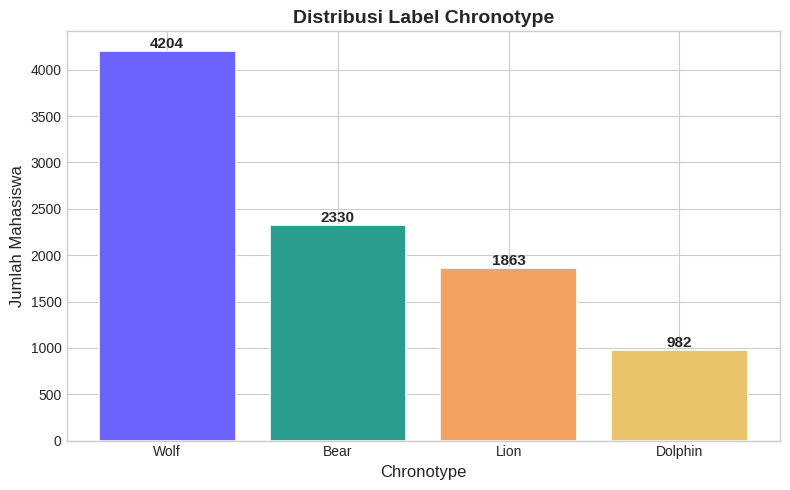


⚠️  Catatan: Wolf menggabungkan Evening+Night → kemungkinan kelas dominan.


In [26]:
# ────────────────────────────────────────────────────────────────
# LANGKAH 4: Label Engineering — Assign CHRONOTYPE
#
# Dasar teori (Dr. Michael Breus, "The Power of When"):
#   Lion    🦁 → Morning      : bangun pagi, produktif jam 8–12
#   Bear    🐻 → Afternoon    : mengikuti siklus matahari, puncak jam 10–14
#   Wolf    🐺 → Evening/Night: aktif malam, produktif jam 17–00
#   Dolphin 🐬 → Variable     : tidur tidak teratur, fleksibel
# ────────────────────────────────────────────────────────────────

CHRONOTYPE_MAP = {
    'Morning'  : 'Lion',
    'Afternoon': 'Bear',
    'Evening'  : 'Wolf',
    'Night'    : 'Wolf',    # night owl masuk kategori Wolf
    'Variable' : 'Dolphin'
}

df['chronotype'] = df['preferred_study_time'].map(CHRONOTYPE_MAP)

print("✅ Label Chronotype berhasil di-assign")
print("\nDistribusi Chronotype:")
ct_dist = df['chronotype'].value_counts()
print(ct_dist)

# Visualisasi distribusi label
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(ct_dist.index,
              ct_dist.values,
              color=[CHRON_MAP_COLORS[c] for c in ct_dist.index],
              edgecolor='white', linewidth=1.2)
ax.set_title('Distribusi Label Chronotype', fontsize=14, fontweight='bold')
ax.set_xlabel('Chronotype', fontsize=12)
ax.set_ylabel('Jumlah Mahasiswa', fontsize=12)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(int(bar.get_height())), ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n⚠️  Catatan: Wolf menggabungkan Evening+Night → kemungkinan kelas dominan.")

Langkah 8 : Transformai/Encoding

In [27]:
# ────────────────────────────────────────────────────────────────
# LANGKAH 5: Transformasi / Encoding (FINAL - CLEAN & NO LEAKAGE)
# ────────────────────────────────────────────────────────────────

df_model = df.copy()

# ❌ 1. Hapus fitur penyebab data leakage
df_model = df_model.drop('preferred_study_time', axis=1)

# 2. Boolean → numerik
df_model['uses_study_aids'] = df_model['uses_study_aids'].astype(str).str.strip()
df_model['uses_study_aids'] = df_model['uses_study_aids'].map(
    {'True': 1, 'False': 0, '1': 1, '0': 0}
).fillna(0).astype(int)

# 3. Encoding fitur kategorikal (untuk Naive Bayes)
le_loc   = LabelEncoder()
le_meth  = LabelEncoder()
le_chron = LabelEncoder()

df_model['loc_enc']    = le_loc.fit_transform(df_model['study_location'])
df_model['meth_enc']   = le_meth.fit_transform(df_model['study_method'])
df_model['chron_enc']  = le_chron.fit_transform(df_model['chronotype'])

# ❌ 4. Hapus fitur mentah + fitur binning (tidak dipakai di Bayes)
df_model = df_model.drop([
    'study_location',
    'study_method',
    'chronotype'
], axis=1)

# (Opsional tapi direkomendasikan untuk Bayes → hindari duplikasi info)
# Tidak gunakan binning untuk GaussianNB
# jadi kita TIDAK pakai: hours_bin, proc_bin, hbin_enc, pbin_enc

# Jika sebelumnya sudah dibuat, drop sekalian (aman)
df_model = df_model.drop(
    [col for col in ['hours_bin', 'proc_bin', 'hbin_enc', 'pbin_enc'] if col in df_model.columns],
    axis=1
)

print("\nKolom akhir:")
print(df_model.columns)

print("\n📋 Preview df_model:")
df_model.head()


Kolom akhir:
Index(['study_hours_weekly', 'procrastination_level', 'uses_study_aids',
       'loc_enc', 'meth_enc', 'chron_enc'],
      dtype='object')

📋 Preview df_model:


,study_hours_weekly,procrastination_level,uses_study_aids,loc_enc,meth_enc,chron_enc
0,5.1,4.0,1,2,1,0
1,7.5,3.0,1,2,2,3
2,4.3,5.0,1,2,3,1
3,13.8,3.0,1,2,2,3
4,12.3,3.0,1,2,2,0


In [28]:
print(df_model.columns)

Index(['study_hours_weekly', 'procrastination_level', 'uses_study_aids',
       'loc_enc', 'meth_enc', 'chron_enc'],
      dtype='object')


# **Implementasi : Model Bayess**

CEK DISTRIBUSI KELAS (Imbalanced Check)
chron_enc
3    4204
0    2330
2    1863
1     982
Name: count, dtype: int64

Proporsi kelas:
chron_enc
3    44.82%
0    24.84%
2    19.86%
1    10.47%
Name: proportion, dtype: object

Mapping label:
  0 → Bear
  1 → Dolphin
  2 → Lion
  3 → Wolf
HASIL CROSS-VALIDATION (5-Fold)
CV Accuracy per fold : [0.4483 0.4483 0.4483 0.4483 0.448 ]
CV Accuracy rata-rata: 0.4482
Standar Deviasi      : 0.0001
Accuracy: 0.4482942430703625

Classification Report:
               precision    recall  f1-score   support

        Bear       0.00      0.00      0.00       466
     Dolphin       0.00      0.00      0.00       196
        Lion       0.00      0.00      0.00       373
        Wolf       0.45      1.00      0.62       841

    accuracy                           0.45      1876
   macro avg       0.11      0.25      0.15      1876
weighted avg       0.20      0.45      0.28      1876


Confusion Matrix:
 [[  0   0   0 466]
 [  0   0   0 196]
 [  0   0   0 3

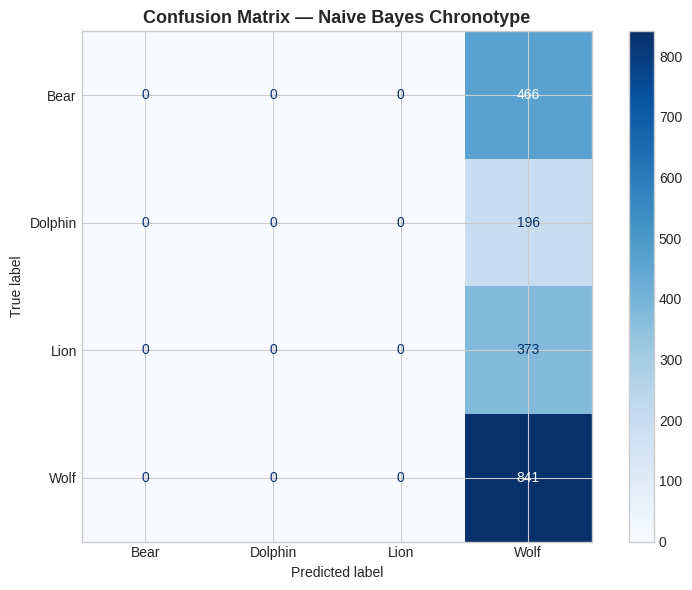

In [29]:
# ─── Langkah 1 : Splitting Data ─────────────────────────────────

# Define X and y
X = df_model.drop('chron_enc', axis=1)
y = df_model['chron_enc']

# ✅ TAMBAHAN BARU — Cek distribusi kelas sebelum split
print("=" * 55)
print("CEK DISTRIBUSI KELAS (Imbalanced Check)")
print("=" * 55)
print(y.value_counts())
print(f"\nProporsi kelas:")
print((y.value_counts(normalize=True) * 100).round(2).astype(str) + '%')

# Keterangan mapping
print(f"\nMapping label:")
for i, cls in enumerate(le_chron.classes_):
    print(f"  {i} → {cls}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # ✅ ini sudah ada di kode kamu — pastikan tidak dihapus!
)

# ─── Langkah 2 : Training ───────────────────────────────────────
model = GaussianNB()
model.fit(X_train, y_train)

# ✅ TAMBAHAN BARU — Cross Validation (letakkan tepat di sini)
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print("=" * 55)
print("HASIL CROSS-VALIDATION (5-Fold)")
print("=" * 55)
print(f"CV Accuracy per fold : {cv_scores.round(4)}")
print(f"CV Accuracy rata-rata: {cv_scores.mean():.4f}")
print(f"Standar Deviasi      : {cv_scores.std():.4f}")

# Langkah 3 : Prediksi
y_pred = model.predict(X_test)

# ─── Langkah 4 : Evaluasi ───────────────────────────────────────
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(
    y_test, y_pred,
    target_names=le_chron.classes_   # ✅ TAMBAHAN: tampilkan nama kelas
))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ✅ GANTI bagian ini:
# ConfusionMatrixDisplay.from_predictions(y_test, y_pred)   ← HAPUS/KOMEN ini

# Dengan versi baru ini:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=le_chron.classes_,   # Bear, Dolphin, Lion, Wolf
    cmap='Blues',
    ax=ax
)
ax.set_title('Confusion Matrix — Naive Bayes Chronotype', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Best var_smoothing: 1.00e-12
✅ Akurasi GaussianNB Tuned : 0.4483 (44.83%)
✅ Akurasi GaussianNB Baseline: 0.4483 (44.83%)

📊 Cross-Validation (5-fold):
   Mean  : 0.4482 (44.82%)
   Std   : ±0.0001
   Scores: ['0.4483', '0.4483', '0.4483', '0.4483', '0.4480']

Laporan Klasifikasi (GaussianNB Tuned):
              precision    recall  f1-score   support

        Bear       0.00      0.00      0.00       466
     Dolphin       0.00      0.00      0.00       196
        Lion       0.00      0.00      0.00       373
        Wolf       0.45      1.00      0.62       841

    accuracy                           0.45      1876
   macro avg       0.11      0.25      0.15      1876
weighted avg       0.20      0.45      0.28      1876



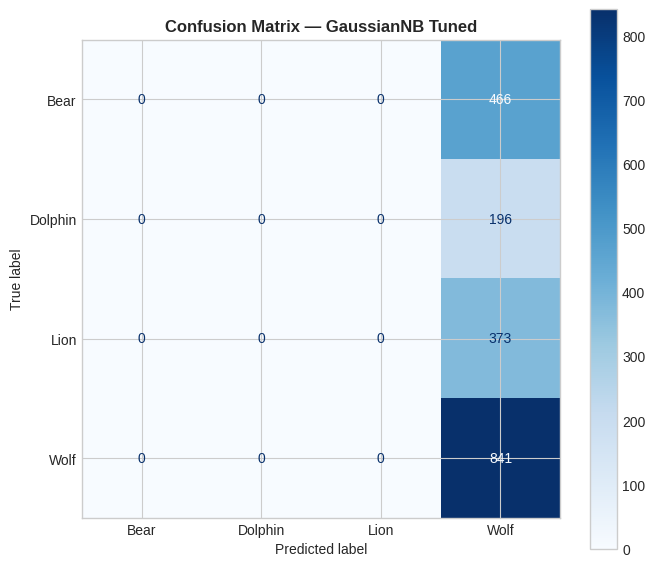

In [30]:
# ── 7C: GaussianNB — Tuning & Validation ─────────────────────────

import numpy as np # Import numpy
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.naive_bayes import GaussianNB # Explicitly import GaussianNB for robustness
from sklearn.model_selection import cross_val_score # Explicitly import cross_val_score
import matplotlib.pyplot as plt # Explicitly import matplotlib.pyplot

# 1. GridSearch for best var_smoothing
params = {'var_smoothing': np.logspace(-12, 0, 50)}
grid = GridSearchCV(GaussianNB(), params, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)
print(f"Best var_smoothing: {grid.best_params_['var_smoothing']:.2e}")

# Define gnb_acc from the previously trained model's accuracy
# Assuming 'model' is the untuned GaussianNB from the previous cell, and 'y_pred' are its predictions
gnb_acc = accuracy_score(y_test, y_pred) # Use y_pred from the previous untuned model

# 2. Evaluate tuned model
gnb_tuned = grid.best_estimator_
gnb_tuned_preds_enc = gnb_tuned.predict(X_test)
gnb_tuned_preds = le_chron.inverse_transform(gnb_tuned_preds_enc)

tuned_acc = accuracy_score(y_test, gnb_tuned_preds_enc)
print(f"✅ Akurasi GaussianNB Tuned : {tuned_acc:.4f} ({tuned_acc*100:.2f}%)")
print(f"✅ Akurasi GaussianNB Baseline: {gnb_acc:.4f} ({gnb_acc*100:.2f}%)")

# 3. Cross-validation on tuned model
cv_scores = cross_val_score(gnb_tuned, X, y, cv=5, scoring='accuracy')
print(f"\n📊 Cross-Validation (5-fold):")
print(f"   Mean  : {cv_scores.mean():.4f} ({cv_scores.mean()*100:.2f}%)")
print(f"   Std   : ±{cv_scores.std():.4f}")
print(f"   Scores: {[f'{s:.4f}' for s in cv_scores]}")

# Define y_test_str and classes_gnb for classification report and confusion matrix
y_test_str = le_chron.inverse_transform(y_test) # Inverse transform y_test to get original labels
classes_gnb = le_chron.classes_ # Get class names from LabelEncoder

# 4. Classification report — check per-class recall
print(f"\nLaporan Klasifikasi (GaussianNB Tuned):")
print(classification_report(y_test_str, gnb_tuned_preds))

# 5. Confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
cm_tuned = confusion_matrix(y_test_str, gnb_tuned_preds, labels=classes_gnb)
ConfusionMatrixDisplay(cm_tuned, display_labels=classes_gnb).plot(ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix — GaussianNB Tuned', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

✅ Akurasi Balanced Priors: 0.2313
              precision    recall  f1-score   support

        Bear       0.26      0.35      0.30       466
     Dolphin       0.11      0.32      0.16       196
        Lion       0.19      0.13      0.16       373
        Wolf       0.41      0.19      0.26       841

    accuracy                           0.23      1876
   macro avg       0.24      0.25      0.22      1876
weighted avg       0.30      0.23      0.24      1876



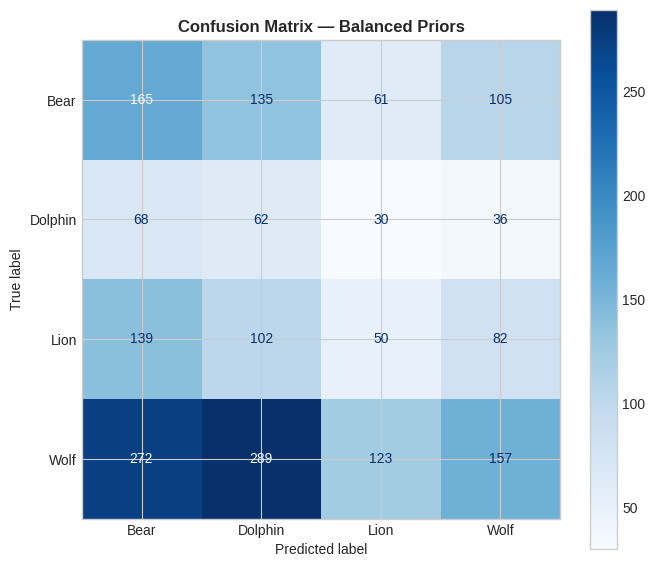

In [31]:
# ── 7D: Equal Priors (if Wolf dominates) ─────────────────────────
gnb_balanced = GaussianNB(priors=[0.25, 0.25, 0.25, 0.25])
gnb_balanced.fit(X_train, y_train)
bal_preds = le_chron.inverse_transform(gnb_balanced.predict(X_test))
print(f"✅ Akurasi Balanced Priors: {accuracy_score(y_test_str, bal_preds):.4f}")
print(classification_report(y_test_str, bal_preds))

# confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
cm_bal = confusion_matrix(y_test_str, bal_preds, labels=classes_gnb)
ConfusionMatrixDisplay(cm_bal, display_labels=classes_gnb).plot(ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix — Balanced Priors', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Decision Tree**

=== DECISION TREE ===
Accuracy: 0.26439232409381663

Classification Report:
               precision    recall  f1-score   support

           0       0.21      0.23      0.22       466
           1       0.08      0.09      0.09       196
           2       0.17      0.18      0.17       373
           3       0.41      0.36      0.39       841

    accuracy                           0.26      1876
   macro avg       0.22      0.22      0.22      1876
weighted avg       0.28      0.26      0.27      1876


Confusion Matrix:
 [[107  57 108 194]
 [ 56  18  46  76]
 [ 97  50  66 160]
 [260  97 179 305]]


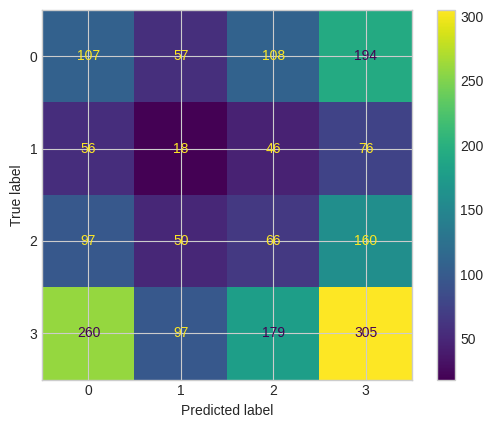

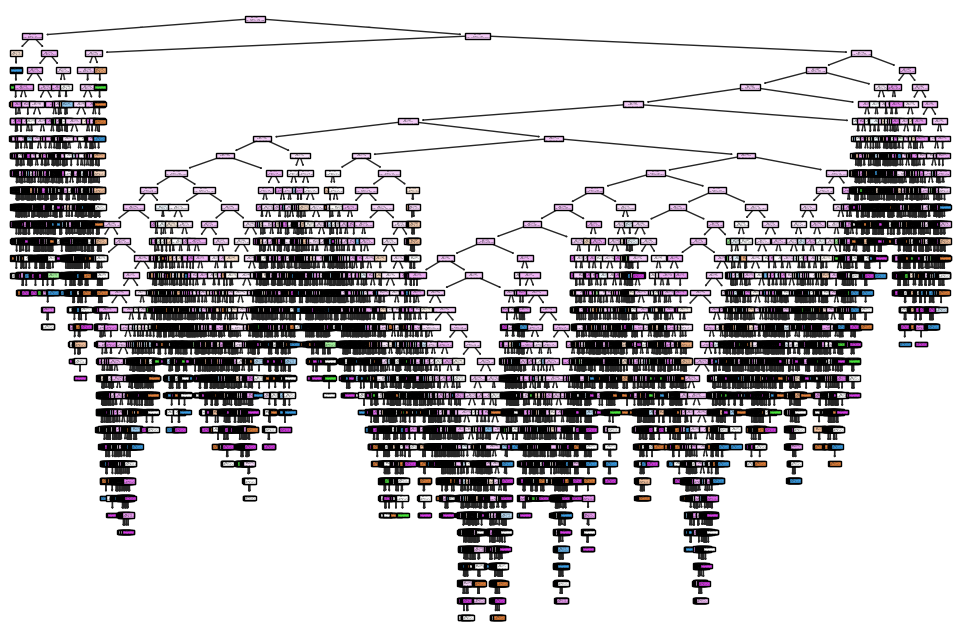

In [32]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print("=== DECISION TREE ===")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt)
plt.show()

from sklearn.tree import plot_tree

plt.figure(figsize=(12,8))
plot_tree(dt_model, filled=True)
plt.show()